# Tarea Académica — Detección de temblor asociado al párkinson con un reloj inteligente

**Curso:** 1INF24 — Inteligencia Artificial  
**Dataset:** MONIPAR (acelerómetro triaxial de smartwatch)  
**Integrantes:** `[Luis Rios, Renzo Roque, Oscar Blas, Estefano Quispe]`  
**Repositorio:** `[https://github.com/Agenthgh]`

---

## Propósito del Colab

Este cuaderno desarrolla un **prototipo de clasificación binaria**:

- **Clase 0:** ventana de reposo sin temblor.
- **Clase 1:** ventana de reposo con temblor ligero o leve.

La entrada corresponde a señales de aceleración en los ejes `x`, `y` y `z` capturadas por un reloj. La salida es una probabilidad de temblor que se usa para simular una alerta cuando varias ventanas consecutivas son clasificadas como positivas.

> **Advertencia:** es un prototipo académico. No constituye diagnóstico médico ni reemplaza la evaluación de profesionales de salud.

## Temas

1. **Exploración y preprocesamiento:** revisión de datos, valores faltantes, distribución de clases y atributos.
2. **Ingeniería de características:** extracción de medidas estadísticas de cada ventana.
3. **Reducción dimensional:** visualización con Análisis de Componentes Principales.
4. **Clasificación supervisada:** Regresión Logística, K vecinos más cercanos y Máquinas de Vectores de Soporte.
5. **Validación:** separación de entrenamiento/prueba y validación cruzada.
6. **Red neuronal:** Perceptrón Multicapa con activación ReLU y salida sigmoide.
7. **Evaluación:** precisión balanceada, precisión, sensibilidad, F1 y matriz de confusión.

### Decisión metodológica

Las ventanas de una misma persona se mantienen en el mismo conjunto. Esto evita que fragmentos muy parecidos de un participante aparezcan simultáneamente en entrenamiento y prueba, lo que produciría una evaluación artificialmente optimista.

## Fuente de datos y publicaciones

- Dataset MONIPAR: https://doi.org/10.5281/zenodo.8104853  
- Sigcha et al. (2023), descripción de MONIPAR: https://doi.org/10.3389/fneur.2023.1326640  
- Sigcha et al. (2021), evaluación automática de temblor con smartwatch: https://doi.org/10.3390/s21010291  
- San-Segundo et al. (2020), detección de temblor con acelerómetros vestibles: https://doi.org/10.3390/s20205817  

MONIPAR registra aceleración triaxial a **50 Hz**. Las etiquetas específicas de temblor son:

- `-1`: señal no etiquetada.
- `0`: reposo sin temblor.
- `1`: temblor ligero.
- `2`: temblor leve.

Para este trabajo, las etiquetas `1` y `2` se agrupan en la clase **con temblor**.

In [29]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

# La mayoría de estas librerías ya están instaladas en Google Colab.
# mat73 se usa únicamente como respaldo si algún archivo .mat está
# guardado en el formato MATLAB v7.3.

!pip -q install mat73

import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import tensorflow as tf

from scipy.io import loadmat
from scipy.signal import detrend, welch
from scipy.stats import kurtosis, skew

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

# Semillas para obtener resultados reproducibles.
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Entorno preparado correctamente.")

TensorFlow: 2.20.0
Entorno preparado correctamente.


In [30]:
# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

# Frecuencia de muestreo reportada por MONIPAR.
FS = 50

# Ventanas de 2 segundos: 2 * 50 = 100 muestras.
WINDOW_SECONDS = 2
WINDOW_SIZE = FS * WINDOW_SECONDS

# Desplazamiento de 1 segundo: 50 % de superposición.
STEP_SECONDS = 1
STEP_SIZE = FS * STEP_SECONDS

# Banda típica usada en la literatura para analizar temblor parkinsoniano.
TREMOR_BAND = (3.5, 7.5)

# Carpeta local de trabajo.
DATA_DIR = Path("/content/monipar_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Archivos necesarios para la clasificación de temblor.
FILES = [
    "MONIPAR_PD_SUPERVISED.mat",
    "MONIPAR_PD_SUPERVISED_TREMOR_LABEL.mat",
    "MONIPAR_PD_REMOTE.mat",
    "MONIPAR_PD_REMOTE_TREMOR_LABEL.mat",
]

print("Tamaño de ventana:", WINDOW_SIZE, "muestras")
print("Desplazamiento:", STEP_SIZE, "muestras")

Tamaño de ventana: 100 muestras
Desplazamiento: 50 muestras


In [31]:
# ============================================================
# 3. DESCARGA DEL DATASET DESDE ZENODO
# ============================================================

BASE_URL = "https://zenodo.org/records/8104853/files"

def download_file(filename, destination):
    """
    Descarga un archivo en bloques.
    Si ya existe, no vuelve a descargarlo.
    """
    destination = Path(destination)

    if destination.exists() and destination.stat().st_size > 0:
        print(f"Ya existe: {filename}")
        return

    url = f"{BASE_URL}/{filename}?download=1"
    print(f"Descargando: {filename}")

    with requests.get(url, stream=True, timeout=180) as response:
        response.raise_for_status()

        with open(destination, "wb") as output_file:
            for block in response.iter_content(chunk_size=1024 * 1024):
                if block:
                    output_file.write(block)

    print(f"Guardado en: {destination}")

download_errors = []

for filename in FILES:
    try:
        download_file(filename, DATA_DIR / filename)
    except Exception as error:
        download_errors.append((filename, str(error)))
        print(f"No se pudo descargar {filename}: {error}")

if download_errors:
    print("\nLa descarga automática falló para uno o más archivos.")
    print("Descárgalos manualmente desde:")
    print("https://doi.org/10.5281/zenodo.8104853")
    print("Luego súbelos a la carpeta:", DATA_DIR)
else:
    print("\nTodos los archivos fueron descargados.")

Ya existe: MONIPAR_PD_SUPERVISED.mat
Ya existe: MONIPAR_PD_SUPERVISED_TREMOR_LABEL.mat
Ya existe: MONIPAR_PD_REMOTE.mat
Ya existe: MONIPAR_PD_REMOTE_TREMOR_LABEL.mat

Todos los archivos fueron descargados.


### Alternativa de carga manual

Solo es necesario ejecutar la siguiente celda cuando la descarga automática falle. Seleccione los cuatro archivos `.mat` indicados en la celda de configuración.

In [32]:
# ============================================================
# 4. FUNCIONES PARA LEER LOS ARCHIVOS MATLAB
# ============================================================

def load_mat_file(path):
    """
    Lee archivos MATLAB tradicionales con scipy.
    Si el archivo es MATLAB v7.3, usa mat73 como respaldo.
    """
    path = str(path)

    try:
        return loadmat(path, squeeze_me=False, struct_as_record=False)
    except NotImplementedError:
        import mat73
        return mat73.loadmat(path)


def find_data_variable(mat_dictionary):
    """
    MONIPAR utiliza una variable principal llamada Data.
    Se conserva una búsqueda alternativa para hacer el código robusto.
    """
    if "Data" in mat_dictionary:
        return mat_dictionary["Data"]

    candidates = [
        value
        for key, value in mat_dictionary.items()
        if not str(key).startswith("__")
    ]

    if not candidates:
        raise ValueError("No se encontró una variable de datos en el archivo .mat.")

    return candidates[0]


def normalize_cell_matrix(data):
    """
    Convierte la estructura de celdas de MATLAB en una matriz de objetos
    donde las filas representan sujetos y las columnas representan semanas.
    """
    if isinstance(data, np.ndarray) and data.dtype == object:
        if data.ndim == 1:
            return data.reshape(-1, 1)
        return data

    if isinstance(data, list):
        array = np.asarray(data, dtype=object)
        if array.ndim == 1:
            array = array.reshape(-1, 1)
        return array

    # Caso excepcional: un único ensayo numérico.
    wrapped = np.empty((1, 1), dtype=object)
    wrapped[0, 0] = data
    return wrapped


def unwrap_singleton(value):
    """
    Elimina capas de arreglos de un solo elemento generadas al leer celdas.
    """
    while isinstance(value, np.ndarray) and value.dtype == object and value.size == 1:
        value = value.item()
    return value


def cell_to_raw_matrix(cell):
    """
    Convierte una celda de datos crudos en una matriz N x 5:
    tiempo, aceleración x, aceleración y, aceleración z y etiqueta de ejercicio.
    """
    value = unwrap_singleton(cell)

    if value is None:
        return np.empty((0, 5))

    array = np.asarray(value)

    if array.size == 0:
        return np.empty((0, 5))

    array = np.squeeze(array)

    if array.ndim != 2:
        return np.empty((0, 5))

    # Algunos lectores pueden entregar la matriz transpuesta.
    if array.shape[1] < 5 and array.shape[0] >= 5:
        array = array.T

    if array.shape[1] < 5:
        return np.empty((0, 5))

    return array[:, :5].astype(float)


def cell_to_label_vector(cell):
    """
    Convierte una celda de etiquetas de temblor en un vector.
    """
    value = unwrap_singleton(cell)

    if value is None:
        return np.array([], dtype=float)

    array = np.asarray(value)

    if array.size == 0:
        return np.array([], dtype=float)

    return np.squeeze(array).astype(float).reshape(-1)


def load_cell_data(path):
    """
    Carga el archivo y devuelve la matriz de celdas.
    """
    mat_dictionary = load_mat_file(path)
    data_variable = find_data_variable(mat_dictionary)
    return normalize_cell_matrix(data_variable)

In [33]:
# ============================================================
# 5. CARGA E INSPECCIÓN DE LOS CUATRO ARCHIVOS
# ============================================================

required_paths = [DATA_DIR / filename for filename in FILES]
missing_files = [str(path) for path in required_paths if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Faltan archivos del dataset. Descárgalos o súbelos manualmente:\n"
        + "\n".join(missing_files)
    )

supervised_raw = load_cell_data(DATA_DIR / "MONIPAR_PD_SUPERVISED.mat")
supervised_labels = load_cell_data(
    DATA_DIR / "MONIPAR_PD_SUPERVISED_TREMOR_LABEL.mat"
)

remote_raw = load_cell_data(DATA_DIR / "MONIPAR_PD_REMOTE.mat")
remote_labels = load_cell_data(
    DATA_DIR / "MONIPAR_PD_REMOTE_TREMOR_LABEL.mat"
)

print("Supervisado - datos:", supervised_raw.shape)
print("Supervisado - etiquetas:", supervised_labels.shape)
print("Remoto - datos:", remote_raw.shape)
print("Remoto - etiquetas:", remote_labels.shape)

Supervisado - datos: (6, 8)
Supervisado - etiquetas: (6, 8)
Remoto - datos: (15, 8)
Remoto - etiquetas: (15, 8)


## Preparación de ventanas y características

No se entrega la señal completa directamente a los modelos clásicos. Primero se divide cada tramo continuo de reposo en ventanas de dos segundos.

Para cada eje y para la magnitud del vector de aceleración se calculan:

- media, desviación estándar, mediana, mínimo, máximo y rango;
- raíz del promedio cuadrático;
- percentiles e intervalo intercuartílico;
- asimetría y curtosis;
- frecuencia dominante;
- potencia total;
- potencia y proporción de potencia en la banda de 3.5 a 7.5 Hz.

La etiqueta de una ventana es positiva cuando al menos la mitad de sus muestras presenta etiqueta de temblor.

In [34]:
# ============================================================
# 6. FUNCIONES DE SEGMENTACIÓN Y EXTRACCIÓN DE CARACTERÍSTICAS
# ============================================================

def contiguous_regions(mask):
    """
    Retorna intervalos [inicio, fin) de valores True consecutivos.
    """
    # Convierte la máscara a booleano para trabajar con True/False
    mask = np.asarray(mask, dtype=bool)

    # Si no hay datos, no hay regiones
    if mask.size == 0:
        return []

    # Detecta cambios entre False->True y True->False
    changes = np.diff(mask.astype(int))

    # Inicios de regiones True
    starts = list(np.where(changes == 1)[0] + 1)

    # Fines de regiones True
    ends = list(np.where(changes == -1)[0] + 1)

    # Si la primera muestra ya es True, la región empieza en 0
    if mask[0]:
        starts = [0] + starts

    # Si la última muestra es True, la región termina al final
    if mask[-1]:
        ends = ends + [len(mask)]

    return list(zip(starts, ends))


def safe_skew(signal):
    # Calcula la asimetría y evita devolver NaN o infinito
    value = skew(signal, bias=False, nan_policy="omit")
    return 0.0 if not np.isfinite(value) else float(value)


def safe_kurtosis(signal):
    # Calcula la curtosis y evita devolver NaN o infinito
    value = kurtosis(signal, bias=False, nan_policy="omit")
    return 0.0 if not np.isfinite(value) else float(value)


def spectral_features(signal, fs=FS, band=TREMOR_BAND):
    """
    Calcula características frecuenciales usando Welch.
    """
    # Elimina tendencia para analizar mejor la variación de la señal
    clean_signal = detrend(np.asarray(signal, dtype=float))

    # Calcula la densidad espectral de potencia
    frequencies, power = welch(
        clean_signal,
        fs=fs,
        nperseg=min(256, len(clean_signal)),
    )

    # Potencia total de la señal
    total_power = float(np.trapz(power, frequencies))

    # Selecciona la banda típica de temblor
    band_mask = (frequencies >= band[0]) & (frequencies <= band[1])

    # Calcula la potencia dentro de la banda de temblor
    if np.sum(band_mask) >= 2:
        band_power = float(
            np.trapz(power[band_mask], frequencies[band_mask])
        )
    else:
        band_power = 0.0

    # Frecuencia donde aparece la mayor potencia
    dominant_frequency = float(frequencies[np.argmax(power)])

    # Proporción de potencia ubicada en la banda de temblor
    band_ratio = band_power / total_power if total_power > 0 else 0.0

    return {
        "dominant_frequency": dominant_frequency,
        "total_power": total_power,
        "tremor_band_power": band_power,
        "tremor_band_ratio": band_ratio,
    }


def extract_channel_features(signal, prefix):
    """
    Extrae características de tiempo y frecuencia para un canal.
    """
    # Limpia la señal quitando la tendencia
    clean_signal = detrend(np.asarray(signal, dtype=float))

    # Percentiles usados para calcular el rango intercuartílico
    q25 = float(np.percentile(clean_signal, 25))
    q75 = float(np.percentile(clean_signal, 75))

    # Características estadísticas de la señal
    features = {
        f"{prefix}_mean": float(np.mean(clean_signal)),
        f"{prefix}_std": float(np.std(clean_signal)),
        f"{prefix}_median": float(np.median(clean_signal)),
        f"{prefix}_min": float(np.min(clean_signal)),
        f"{prefix}_max": float(np.max(clean_signal)),
        f"{prefix}_range": float(np.ptp(clean_signal)),
        f"{prefix}_rms": float(np.sqrt(np.mean(clean_signal ** 2))),
        f"{prefix}_p25": q25,
        f"{prefix}_p75": q75,
        f"{prefix}_iqr": q75 - q25,
        f"{prefix}_skew": safe_skew(clean_signal),
        f"{prefix}_kurtosis": safe_kurtosis(clean_signal),
        f"{prefix}_zero_cross_rate": float(
            np.mean(np.diff(np.signbit(clean_signal)) != 0)
        ),
    }

    # Características en frecuencia
    spectrum = spectral_features(clean_signal)

    # Agrega las características frecuenciales al diccionario
    for feature_name, value in spectrum.items():
        features[f"{prefix}_{feature_name}"] = value

    return features


def extract_window_features(window_xyz):
    """
    Extrae características de los ejes x, y, z y de la magnitud.
    """
    # Se separan los tres ejes de aceleración
    x_axis = window_xyz[:, 0]
    y_axis = window_xyz[:, 1]
    z_axis = window_xyz[:, 2]

    # Se calcula la magnitud de la aceleración
    magnitude = np.sqrt(x_axis ** 2 + y_axis ** 2 + z_axis ** 2)

    features = {}

    # Extrae características para cada eje y para la magnitud
    for signal, prefix in [
        (x_axis, "x"),
        (y_axis, "y"),
        (z_axis, "z"),
        (magnitude, "magnitude"),
    ]:
        features.update(extract_channel_features(signal, prefix))

    return features


def build_feature_dataset(raw_cells, label_cells, group_name):
    """
    Recorre sujetos y semanas, crea ventanas y extrae características.
    """
    # Lista donde se guardará una fila por cada ventana
    rows = []

    # Guarda una ventana de ejemplo para graficarla después
    example_window = None

    # Se limita el recorrido al tamaño común entre datos y etiquetas
    max_subjects = min(raw_cells.shape[0], label_cells.shape[0])
    max_weeks = min(raw_cells.shape[1], label_cells.shape[1])

    # Recorre cada sujeto y semana
    for subject_index in range(max_subjects):
        for week_index in range(max_weeks):

            # Convierte las celdas del archivo .mat a arreglos utilizables
            raw = cell_to_raw_matrix(raw_cells[subject_index, week_index])
            tremor_labels = cell_to_label_vector(
                label_cells[subject_index, week_index]
            )

            # Si no hay datos o etiquetas, se omite el caso
            if len(raw) == 0 or len(tremor_labels) == 0:
                continue

            # Asegura que señal y etiquetas tengan la misma longitud
            usable_length = min(len(raw), len(tremor_labels))
            raw = raw[:usable_length]
            tremor_labels = tremor_labels[:usable_length]

            # Columna 5 del dato crudo: etiqueta del ejercicio
            exercise_labels = raw[:, 4]

            # Se usan solo muestras de reposo con etiqueta válida
            valid_mask = (exercise_labels == 1) & (tremor_labels >= 0)

            # Procesa cada región continua de reposo etiquetado
            for segment_number, (start, end) in enumerate(
                contiguous_regions(valid_mask)
            ):
                segment_raw = raw[start:end]
                segment_tremor = tremor_labels[start:end]

                # Si el segmento es menor que la ventana, no se usa
                if len(segment_raw) < WINDOW_SIZE:
                    continue

                # Recorre el segmento usando ventanas deslizantes
                for local_start in range(
                    0,
                    len(segment_raw) - WINDOW_SIZE + 1,
                    STEP_SIZE,
                ):
                    local_end = local_start + WINDOW_SIZE

                    # Extrae la ventana de señal y sus etiquetas
                    window = segment_raw[local_start:local_end]
                    window_labels = segment_tremor[local_start:local_end]

                    # Proporción de muestras con temblor dentro de la ventana
                    positive_fraction = float(np.mean(window_labels > 0))

                    # La ventana se marca como temblor si al menos 50 % es positivo
                    binary_target = int(positive_fraction >= 0.50)

                    # Usa el tiempo real si existe; si no, lo estima con FS
                    valid_timestamp = np.isfinite(window[0, 0])
                    start_time_ms = (
                        float(window[0, 0])
                        if valid_timestamp
                        else float((start + local_start) * 1000 / FS)
                    )

                    # Información de la ventana
                    row = {
                        "group": group_name,
                        "subject": f"{group_name}_S{subject_index + 1:02d}",
                        "week": week_index + 1,
                        "segment": segment_number + 1,
                        "start_time_ms": start_time_ms,
                        "positive_fraction": positive_fraction,
                        "tremor_severity_max": int(np.max(window_labels)),
                        "target": binary_target,
                    }

                    # Agrega las características extraídas de x, y, z
                    row.update(extract_window_features(window[:, 1:4]))

                    # Guarda la fila en el dataset final
                    rows.append(row)

                    # Guarda la primera ventana como ejemplo visual
                    if example_window is None:
                        example_window = {
                            "time_seconds": np.arange(WINDOW_SIZE) / FS,
                            "xyz": window[:, 1:4].copy(),
                            "labels": window_labels.copy(),
                            "target": binary_target,
                            "subject": row["subject"],
                            "week": row["week"],
                        }

    # Devuelve el dataset de características y una ventana de ejemplo
    return pd.DataFrame(rows), example_window

In [35]:
# ============================================================
# 7. GENERACIÓN DEL DATASET TABULAR
# ============================================================

supervised_features, supervised_example = build_feature_dataset(
    supervised_raw,
    supervised_labels,
    "SUPERVISED",
)

remote_features, remote_example = build_feature_dataset(
    remote_raw,
    remote_labels,
    "REMOTE",
)

features_df = pd.concat(
    [supervised_features, remote_features],
    ignore_index=True,
)

if features_df.empty:
    raise ValueError(
        "No se generaron ventanas. Revise la estructura de los archivos .mat."
    )

example_window = (
    supervised_example
    if supervised_example is not None
    else remote_example
)

print("Número de ventanas:", len(features_df))
print("Número de sujetos:", features_df["subject"].nunique())
print("Número total de columnas:", features_df.shape[1])

display(features_df.head())

Número de ventanas: 20071
Número de sujetos: 18
Número total de columnas: 76


,group,subject,week,segment,start_time_ms,positive_fraction,tremor_severity_max,target,x_mean,x_std,...,magnitude_p25,magnitude_p75,magnitude_iqr,magnitude_skew,magnitude_kurtosis,magnitude_zero_cross_rate,magnitude_dominant_frequency,magnitude_total_power,magnitude_tremor_band_power,magnitude_tremor_band_ratio
0,SUPERVISED,SUPERVISED_S01,1,1,493.0,0.0,0,0,-6.616929e-16,0.017666,...,-0.004641,0.004149,0.008791,0.214115,-0.325586,0.272727,4.5,0.000034,0.000020,0.587248
1,SUPERVISED,SUPERVISED_S01,1,1,1439.0,0.0,0,0,-1.016964e-15,0.017824,...,-0.007004,0.007470,0.014475,-0.164530,0.271299,0.191919,3.5,0.000117,0.000046,0.391630
2,SUPERVISED,SUPERVISED_S01,1,1,2385.0,0.0,0,0,-2.264855e-16,0.026225,...,-0.010024,0.009436,0.019459,0.403027,-0.064035,0.191919,3.5,0.000228,0.000073,0.322895
3,SUPERVISED,SUPERVISED_S01,1,1,3331.0,0.0,0,0,-4.973799e-16,0.028533,...,-0.008569,0.006039,0.014608,0.574168,0.391398,0.222222,3.5,0.000137,0.000054,0.396706
4,SUPERVISED,SUPERVISED_S01,1,1,4277.0,0.0,0,0,-1.776357e-16,0.019465,...,-0.005892,0.005714,0.011606,-0.097617,0.191154,0.242424,4.0,0.000077,0.000044,0.575948


In [36]:
# ============================================================
# 8. GUARDADO DEL DATASET PROCESADO
# ============================================================

FEATURES_PATH = "/content/monipar_tremor_features.csv"
features_df.to_csv(FEATURES_PATH, index=False)

print("Dataset de características guardado en:")
print(FEATURES_PATH)

Dataset de características guardado en:
/content/monipar_tremor_features.csv


## Exploración inicial

Esta sección revisa la señal, el balance de clases, los valores faltantes y las estadísticas descriptivas. La variable objetivo no se usa como atributo predictor.

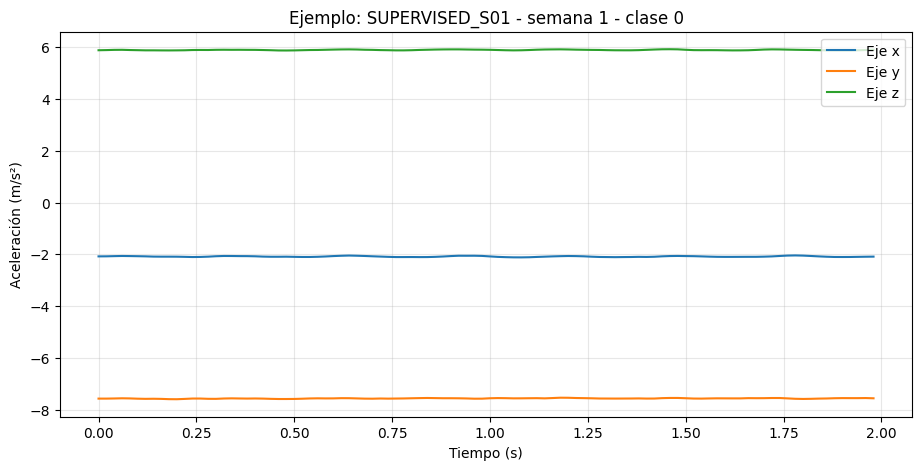

In [37]:
# ============================================================
# 9. VISUALIZACIÓN DE UNA VENTANA DE ACELERACIÓN
# ============================================================

plt.figure(figsize=(11, 5))
plt.plot(example_window["time_seconds"], example_window["xyz"][:, 0], label="Eje x")
plt.plot(example_window["time_seconds"], example_window["xyz"][:, 1], label="Eje y")
plt.plot(example_window["time_seconds"], example_window["xyz"][:, 2], label="Eje z")
plt.xlabel("Tiempo (s)")
plt.ylabel("Aceleración (m/s²)")
plt.title(
    f"Ejemplo: {example_window['subject']} - semana {example_window['week']} "
    f"- clase {example_window['target']}"
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

,cantidad,porcentaje
Sin temblor,14400,71.75
Con temblor,5671,28.25


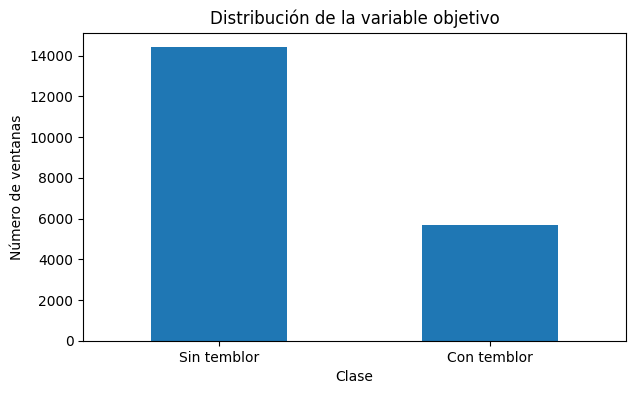

In [38]:
# ============================================================
# 10. DISTRIBUCIÓN DE CLASES
# ============================================================

# Se cuentan las ventanas por clase: 0 = sin temblor, 1 = con temblor
class_counts = features_df["target"].value_counts().sort_index()

# Se calcula el porcentaje que representa cada clase
class_percentages = (
    features_df["target"].value_counts(normalize=True).sort_index() * 100
)

# Se arma una tabla resumen con cantidades y porcentajes
class_summary = pd.DataFrame({
    "cantidad": class_counts,
    "porcentaje": class_percentages.round(2),
})

# Se cambian las etiquetas numéricas por nombres más claros
class_summary.index = [
    "Sin temblor" if index == 0 else "Con temblor"
    for index in class_summary.index
]

# Se muestra la tabla de distribución de clases
display(class_summary)

# Se grafica la cantidad de ventanas por clase
plt.figure(figsize=(7, 4))
class_counts.plot(kind="bar")

plt.xlabel("Clase")
plt.ylabel("Número de ventanas")
plt.title("Distribución de la variable objetivo")

# Se muestran nombres descriptivos en el eje x
plt.xticks(
    range(len(class_counts)),
    [
        "Sin temblor" if index == 0 else "Con temblor"
        for index in class_counts.index
    ],
    rotation=0,
)

plt.show()

In [39]:
# ============================================================
# 11. VALORES FALTANTES Y ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

# Columnas que describen la ventana, pero no son atributos de entrada del modelo
metadata_columns = [
    "group",
    "subject",
    "week",
    "segment",
    "start_time_ms",
    "positive_fraction",
    "tremor_severity_max",
    "target",
]

# Se seleccionan solo las columnas de características numéricas
feature_columns = [
    column
    for column in features_df.columns
    if column not in metadata_columns
]

# Se cuenta la cantidad total de valores faltantes en las características
print(
    "Valores faltantes totales:",
    features_df[feature_columns].isna().sum().sum(),
)

# Se cuenta la cantidad total de valores infinitos en las características
print(
    "Valores infinitos totales:",
    np.isinf(features_df[feature_columns]).sum().sum(),
)

# Se reemplazan infinitos por NaN para poder limpiarlos correctamente
features_df[feature_columns] = features_df[feature_columns].replace(
    [np.inf, -np.inf],
    np.nan,
)

# Se eliminan las ventanas que tengan algún atributo faltante
rows_before = len(features_df)
features_df = features_df.dropna(subset=feature_columns).reset_index(drop=True)
rows_after = len(features_df)

# Se muestra cuántas filas fueron eliminadas después de la limpieza
print("Filas eliminadas:", rows_before - rows_after)

# Se muestran estadísticas descriptivas de las primeras características
display(
    features_df[feature_columns]
    .describe()
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .head(15)
)

Valores faltantes totales: 0
Valores infinitos totales: 0
Filas eliminadas: 0


,mean,std,min,25%,50%,75%,max
x_mean,-2.659706e-17,9.569036e-16,-5.755396e-15,-5.417888e-16,-4.440892e-17,4.618528e-16,6.306067e-15
x_std,4.068321e-02,5.566212e-02,2.084001e-03,1.222069e-02,2.178724e-02,4.583863e-02,1.030299e+00
x_median,-1.265138e-04,9.623729e-03,-2.449634e-01,-1.412823e-03,8.246430e-06,1.366044e-03,1.888447e-01
x_min,-9.987462e-02,1.351620e-01,-2.151448e+00,-1.144017e-01,-5.321892e-02,-2.859981e-02,-5.093439e-03
x_max,1.046728e-01,1.543484e-01,4.633097e-03,2.818717e-02,5.329254e-02,1.163614e-01,3.658889e+00
x_range,2.045475e-01,2.822159e-01,1.014661e-02,5.797314e-02,1.079242e-01,2.307073e-01,5.775991e+00
x_rms,4.068321e-02,5.566212e-02,2.084001e-03,1.222069e-02,2.178724e-02,4.583863e-02,1.030299e+00
x_p25,-2.716536e-02,4.153121e-02,-8.022198e-01,-2.874855e-02,-1.402697e-02,-7.997078e-03,-5.773990e-04
x_p75,2.673418e-02,4.016468e-02,-1.425534e-02,7.972793e-03,1.398435e-02,2.844891e-02,9.539658e-01
x_iqr,5.389954e-02,8.108916e-02,2.679122e-03,1.609673e-02,2.821936e-02,5.726386e-02,1.756186e+00


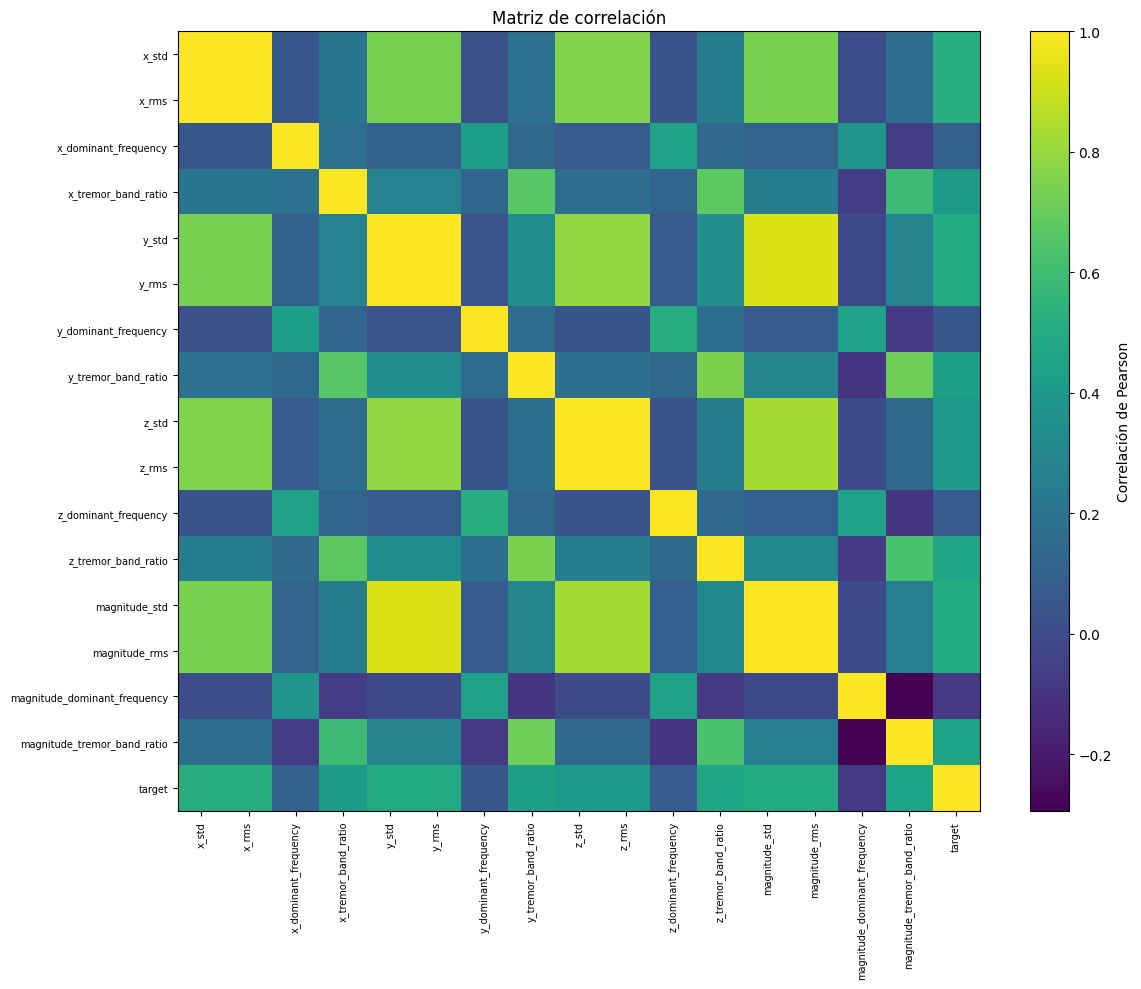

In [40]:
# ============================================================
# 12. MATRIZ DE CORRELACIÓN DE CARACTERÍSTICAS SELECCIONADAS
# ============================================================

# Se seleccionan algunas características importantes para analizar su relación
selected_for_correlation = [
    column
    for column in feature_columns
    if (
        column.endswith("_std")
        or column.endswith("_rms")
        or column.endswith("_dominant_frequency")
        or column.endswith("_tremor_band_ratio")
    )
]

# Se calcula la matriz de correlación incluyendo también la variable objetivo
correlation_matrix = features_df[
    selected_for_correlation + ["target"]
].corr()

# Se crea la figura para mostrar la matriz como mapa de calor
plt.figure(figsize=(12, 10))

# Se grafica la matriz de correlación
image = plt.imshow(correlation_matrix, aspect="auto")

# Se colocan los nombres de las columnas en el eje x
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=7,
)

# Se colocan los nombres de las variables en el eje y
plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index,
    fontsize=7,
)

# Se agrega la barra de color para interpretar la intensidad de correlación
plt.colorbar(image, label="Correlación de Pearson")

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

## Separación por sujetos

Se reserva aproximadamente el 20 % de los sujetos para la prueba final. Los modelos y transformaciones solo se ajustan con el conjunto de entrenamiento.

In [41]:
# ============================================================
# 13. PREPARACIÓN DE X, y Y GRUPOS
# ============================================================

# X contiene las características que usará el modelo
X = features_df[feature_columns].copy()

# y contiene la etiqueta objetivo: 0 = sin temblor, 1 = con temblor
y = features_df["target"].astype(int).copy()

# groups identifica a qué sujeto pertenece cada ventana
groups = features_df["subject"].copy()

def grouped_holdout(X, y, groups, test_size=0.20, initial_seed=SEED):
    """
    Busca una separación por sujetos que contenga ambas clases
    tanto en entrenamiento como en prueba.
    """

    # Se prueban varias semillas hasta encontrar una división válida
    for current_seed in range(initial_seed, initial_seed + 200):

        # Divide los datos respetando los grupos, es decir, los sujetos
        splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=test_size,
            random_state=current_seed,
        )

        # Obtiene los índices de entrenamiento y prueba
        train_index, test_index = next(
            splitter.split(X, y, groups=groups)
        )

        # Verifica que ambos conjuntos tengan las dos clases
        if (
            len(np.unique(y.iloc[train_index])) == 2
            and len(np.unique(y.iloc[test_index])) == 2
        ):
            return train_index, test_index, current_seed

    # Si no se encuentra una división válida, se detiene el programa
    raise ValueError(
        "No se encontró una separación por sujetos con ambas clases."
    )

# Se obtiene la separación final por sujetos
train_index, test_index, split_seed = grouped_holdout(X, y, groups)

# Se separan las características de entrenamiento y prueba
X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

# Se separan las etiquetas de entrenamiento y prueba
y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

# Se guardan los sujetos correspondientes a cada conjunto
groups_train = groups.iloc[train_index].copy()
groups_test = groups.iloc[test_index].copy()

# Se muestran los detalles de la división realizada
print("Semilla usada:", split_seed)
print("Ventanas de entrenamiento:", len(X_train))
print("Ventanas de prueba:", len(X_test))
print("Sujetos de entrenamiento:", groups_train.nunique())
print("Sujetos de prueba:", groups_test.nunique())
print("Sujetos reservados para prueba:", sorted(groups_test.unique()))

Semilla usada: 42
Ventanas de entrenamiento: 16735
Ventanas de prueba: 3336
Sujetos de entrenamiento: 14
Sujetos de prueba: 4
Sujetos reservados para prueba: ['REMOTE_S01', 'REMOTE_S02', 'REMOTE_S07', 'REMOTE_S11']


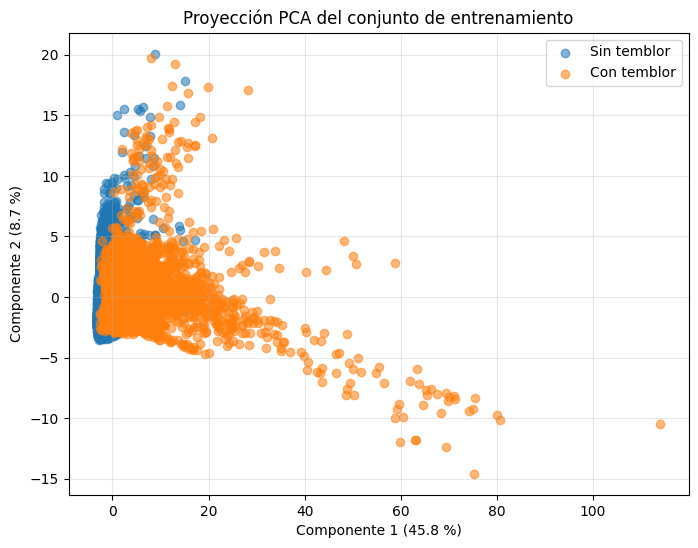

Varianza explicada acumulada: 54.52 %


In [42]:
# ============================================================
# 14. PCA PARA VISUALIZAR LOS DATOS
# ============================================================

# PCA se usa solo para visualizar los datos en 2 dimensiones,
# no para reemplazar la evaluación de los clasificadores.

# Se estandarizan las características antes de aplicar PCA
scaler_for_visualization = StandardScaler()
X_train_scaled_visualization = scaler_for_visualization.fit_transform(X_train)

# Se reduce el conjunto de entrenamiento a 2 componentes principales
pca_visualization = PCA(n_components=2)
X_train_pca = pca_visualization.fit_transform(
    X_train_scaled_visualization
)

# Se crea un DataFrame con las dos componentes y la clase real
pca_df = pd.DataFrame({
    "PC1": X_train_pca[:, 0],
    "PC2": X_train_pca[:, 1],
    "target": y_train.to_numpy(),
})

# Se crea la figura para la gráfica PCA
plt.figure(figsize=(8, 6))

# Se grafican por separado las ventanas sin temblor y con temblor
for class_value, class_name in [(0, "Sin temblor"), (1, "Con temblor")]:
    subset = pca_df[pca_df["target"] == class_value]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.55,
        label=class_name,
    )

# Etiquetas de los ejes con el porcentaje de varianza explicada
plt.xlabel(
    f"Componente 1 ({pca_visualization.explained_variance_ratio_[0] * 100:.1f} %)"
)
plt.ylabel(
    f"Componente 2 ({pca_visualization.explained_variance_ratio_[1] * 100:.1f} %)"
)

plt.title("Proyección PCA del conjunto de entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Se muestra cuánta información conservan las dos componentes principales
print(
    "Varianza explicada acumulada:",
    round(pca_visualization.explained_variance_ratio_.sum() * 100, 2),
    "%",
)

## Modelos clásicos

Se comparan seis pipelines:

- Regresión Logística, KNN y SVM.
- Cada modelo se prueba con estandarización, y también con estandarización más PCA que conserva el 95 % de la varianza.

La selección se realiza con **F1 promedio** en validación cruzada agrupada por sujeto. También se reporta precisión balanceada porque puede existir desbalance entre ventanas con y sin temblor.

In [43]:
# ============================================================
# 15. DEFINICIÓN DE PIPELINES CANDIDATOS
# ============================================================

# Se definen los modelos que se van a comparar
models = {
    "Regresión Logística": LogisticRegression(
        max_iter=2000,              # Aumenta iteraciones para asegurar convergencia
        class_weight="balanced",    # Compensa el desbalance entre clases
        random_state=SEED,
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5,              # Usa los 5 vecinos más cercanos
    ),
    "SVM RBF": SVC(
        kernel="rbf",               # Kernel no lineal
        C=1.0,
        gamma="scale",
        class_weight="balanced",    # Compensa el desbalance entre clases
        probability=True,           # Permite obtener probabilidades
        random_state=SEED,
    ),
}

# Diccionario donde se guardarán los pipelines completos
pipelines = {}

# Para cada modelo se crea una versión sin PCA y otra con PCA
for model_name, model in models.items():

    # Pipeline sin reducción dimensional
    pipelines[f"{model_name} sin PCA"] = Pipeline([
        ("scaler", StandardScaler()),      # Normaliza las características
        ("classifier", clone(model)),      # Clasificador a entrenar
    ])

    # Pipeline con PCA conservando el 95 % de la varianza
    pipelines[f"{model_name} con PCA"] = Pipeline([
        ("scaler", StandardScaler()),      # Normaliza antes de aplicar PCA
        ("pca", PCA(n_components=0.95)),   # Reduce dimensión manteniendo 95 % de varianza
        ("classifier", clone(model)),      # Clasificador a entrenar
    ])

# Se imprimen los pipelines generados
print("Pipelines candidatos:")
for pipeline_name in pipelines:
    print("-", pipeline_name)

Pipelines candidatos:
- Regresión Logística sin PCA
- Regresión Logística con PCA
- KNN sin PCA
- KNN con PCA
- SVM RBF sin PCA
- SVM RBF con PCA


In [44]:
# ============================================================
# 16. VALIDACIÓN CRUZADA AGRUPADA POR SUJETO
# ============================================================

# Se obtiene la cantidad de sujetos disponibles en entrenamiento
number_of_subjects = groups_train.nunique()

# Se usan como máximo 5 particiones, sin superar el número de sujetos
number_of_splits = min(5, number_of_subjects)

# Se valida que haya suficientes sujetos para hacer validación cruzada
if number_of_splits < 2:
    raise ValueError("Se requieren al menos dos sujetos para validar.")

# Validación cruzada estratificada y agrupada por sujeto
cross_validation = StratifiedGroupKFold(
    n_splits=number_of_splits,
    shuffle=True,
    random_state=SEED,
)

# Métricas que se evaluarán en cada partición
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

# Lista para guardar los resultados de cada pipeline
cv_rows = []

# Se evalúa cada pipeline usando validación cruzada
for pipeline_name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        groups=groups_train,       # Evita mezclar ventanas del mismo sujeto
        cv=cross_validation,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )

    # Se guardan los promedios de las métricas obtenidas
    cv_rows.append({
        "pipeline": pipeline_name,
        "accuracy_mean": np.mean(scores["test_accuracy"]),
        "balanced_accuracy_mean": np.mean(
            scores["test_balanced_accuracy"]
        ),
        "precision_mean": np.mean(scores["test_precision"]),
        "recall_mean": np.mean(scores["test_recall"]),
        "f1_mean": np.mean(scores["test_f1"]),
        "f1_std": np.std(scores["test_f1"]),
    })

# Se ordenan los modelos según F1 y balanced accuracy
cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(
        by=["f1_mean", "balanced_accuracy_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)

# Se muestran los resultados de validación cruzada
display(cv_results.round(4))

,pipeline,accuracy_mean,balanced_accuracy_mean,precision_mean,recall_mean,f1_mean,f1_std
0,Regresión Logística sin PCA,0.9373,0.9029,0.7867,0.8604,0.8216,0.0965
1,SVM RBF sin PCA,0.9334,0.9064,0.7657,0.8747,0.8159,0.0969
2,Regresión Logística con PCA,0.9333,0.8939,0.7818,0.8453,0.8111,0.0948
3,SVM RBF con PCA,0.9311,0.9011,0.7607,0.8658,0.8091,0.0997
4,KNN con PCA,0.9195,0.8262,0.8122,0.6863,0.7409,0.1251
5,KNN sin PCA,0.9177,0.8177,0.8067,0.6689,0.7281,0.1398


In [45]:
# ============================================================
# 17. SELECCIÓN Y ENTRENAMIENTO DEL MEJOR MODELO CLÁSICO
# ============================================================

best_pipeline_name = cv_results.loc[0, "pipeline"]
best_classical_model = clone(pipelines[best_pipeline_name])

best_classical_model.fit(X_train, y_train)

print("Pipeline seleccionado:", best_pipeline_name)
print(
    "F1 promedio en validación:",
    round(cv_results.loc[0, "f1_mean"], 4),
)

Pipeline seleccionado: Regresión Logística sin PCA
F1 promedio en validación: 0.8216


,modelo,accuracy,balanced_accuracy,precision,recall,f1
0,Regresión Logística sin PCA,0.8639,0.8603,0.8215,0.9443,0.8786


Reporte de clasificación:
              precision    recall  f1-score   support

 Sin temblor       0.93      0.78      0.85      1596
 Con temblor       0.82      0.94      0.88      1740

    accuracy                           0.86      3336
   macro avg       0.87      0.86      0.86      3336
weighted avg       0.87      0.86      0.86      3336



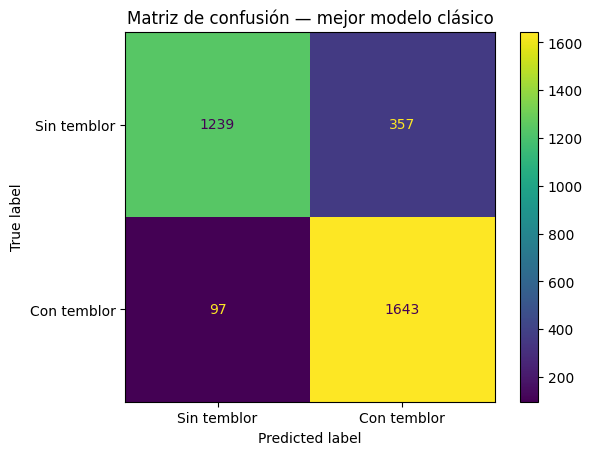

In [46]:
# ============================================================
# 18. EVALUACIÓN FINAL DEL MODELO CLÁSICO
# ============================================================

y_pred_classical = best_classical_model.predict(X_test)

classical_metrics = {
    "modelo": best_pipeline_name,
    "accuracy": accuracy_score(y_test, y_pred_classical),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        y_pred_classical,
    ),
    "precision": precision_score(
        y_test,
        y_pred_classical,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        y_pred_classical,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test,
        y_pred_classical,
        zero_division=0,
    ),
}

display(pd.DataFrame([classical_metrics]).round(4))

print("Reporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred_classical,
        target_names=["Sin temblor", "Con temblor"],
        zero_division=0,
    )
)

matrix = confusion_matrix(y_test, y_pred_classical)
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["Sin temblor", "Con temblor"],
)
display_matrix.plot()
plt.title("Matriz de confusión — mejor modelo clásico")
plt.show()

## Perceptrón Multicapa

La red recibe las características estandarizadas. Usa:

- dos capas ocultas con activación ReLU;
- una neurona de salida con activación sigmoide;
- pérdida de entropía cruzada binaria;
- optimizador Adam con tasa de aprendizaje de `0.001`;
- parada temprana para reducir sobreajuste.

In [47]:
# ============================================================
# 19. SEPARACIÓN DE VALIDACIÓN PARA LA RED NEURONAL
# ============================================================

def grouped_validation_split(X, y, groups, validation_size=0.20):
    """
    Separa sujetos de entrenamiento y validación.
    """

    # Se prueban varias semillas hasta encontrar una división válida
    for current_seed in range(SEED, SEED + 200):

        # Divide los datos sin mezclar sujetos entre entrenamiento y validación
        splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=validation_size,
            random_state=current_seed,
        )

        # Obtiene los índices para entrenamiento interno y validación
        inner_train_index, validation_index = next(
            splitter.split(X, y, groups=groups)
        )

        # Verifica que ambos conjuntos tengan las dos clases
        if (
            len(np.unique(y.iloc[inner_train_index])) == 2
            and len(np.unique(y.iloc[validation_index])) == 2
        ):
            return inner_train_index, validation_index

    # Si ninguna división sirve, se detiene el proceso
    raise ValueError(
        "No fue posible crear validación por sujetos con ambas clases."
    )

# Se separa el entrenamiento original en entrenamiento interno y validación
inner_train_index, validation_index = grouped_validation_split(
    X_train,
    y_train,
    groups_train,
)

# Datos usados para entrenar la red neuronal
X_inner_train = X_train.iloc[inner_train_index]
y_inner_train = y_train.iloc[inner_train_index]

# Datos usados para validar la red durante el entrenamiento
X_validation = X_train.iloc[validation_index]
y_validation = y_train.iloc[validation_index]

# Escalador para normalizar las características del MLP
mlp_scaler = StandardScaler()

# Se ajusta el escalador solo con entrenamiento interno
X_inner_train_scaled = mlp_scaler.fit_transform(X_inner_train)

# Se aplica la misma normalización a validación y prueba
X_validation_scaled = mlp_scaler.transform(X_validation)
X_test_scaled = mlp_scaler.transform(X_test)

# Se muestran las dimensiones finales de cada conjunto
print("Entrenamiento MLP:", X_inner_train_scaled.shape)
print("Validación MLP:", X_validation_scaled.shape)
print("Prueba MLP:", X_test_scaled.shape)

Entrenamiento MLP: (11534, 68)
Validación MLP: (5201, 68)
Prueba MLP: (3336, 68)


In [48]:
# ============================================================
# 20. CONSTRUCCIÓN Y ENTRENAMIENTO DEL MLP
# ============================================================

# Clases del problema: 0 = sin temblor, 1 = con temblor
classes = np.array([0, 1])

# Se calculan pesos para compensar el desbalance entre clases
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_inner_train,
)

# Se guardan los pesos en el formato que usa Keras
class_weights = {
    int(class_value): float(weight)
    for class_value, weight in zip(classes, weights)
}

# Se define la arquitectura del perceptrón multicapa
mlp_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_inner_train_scaled.shape[1],)),  # Entrada con todas las características
    tf.keras.layers.Dense(64, activation="relu"),                   # Primera capa oculta
    tf.keras.layers.Dropout(0.20),                                  # Reduce sobreajuste
    tf.keras.layers.Dense(32, activation="relu"),                   # Segunda capa oculta
    tf.keras.layers.Dropout(0.20),                                  # Reduce sobreajuste
    tf.keras.layers.Dense(1, activation="sigmoid"),                 # Salida binaria
])

# Se configura el entrenamiento del modelo
mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

# Detiene el entrenamiento si la pérdida de validación deja de mejorar
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
)

# Se entrena el MLP usando validación y pesos de clase
history = mlp_model.fit(
    X_inner_train_scaled,
    y_inner_train,
    validation_data=(
        X_validation_scaled,
        y_validation,
    ),
    epochs=60,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1,
)

# Se muestra el resumen de la arquitectura entrenada
mlp_model.summary()

Epoch 1/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9022 - loss: 0.2491 - precision: 0.6203 - recall: 0.9069 - val_accuracy: 0.9044 - val_loss: 0.2202 - val_precision: 0.8327 - val_recall: 0.9676
Epoch 2/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9247 - loss: 0.1982 - precision: 0.6826 - recall: 0.9356 - val_accuracy: 0.9181 - val_loss: 0.1974 - val_precision: 0.8598 - val_recall: 0.9626
Epoch 3/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9328 - loss: 0.1821 - precision: 0.7101 - recall: 0.9374 - val_accuracy: 0.9277 - val_loss: 0.1949 - val_precision: 0.8944 - val_recall: 0.9393
Epoch 4/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9343 - loss: 0.1747 - precision: 0.7124 - recall: 0.9466 - val_accuracy: 0.9267 - val_loss: 0.2032 - val_precision: 0.8911 - val_recall: 0.9411
Epoch 5/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9368 - loss: 0.1685 - precision: 0.7210 - recall: 0.9477 - val_accuracy: 0.9287 - val_loss: 0.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,589 (76.52 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,060 (51.02 KB)

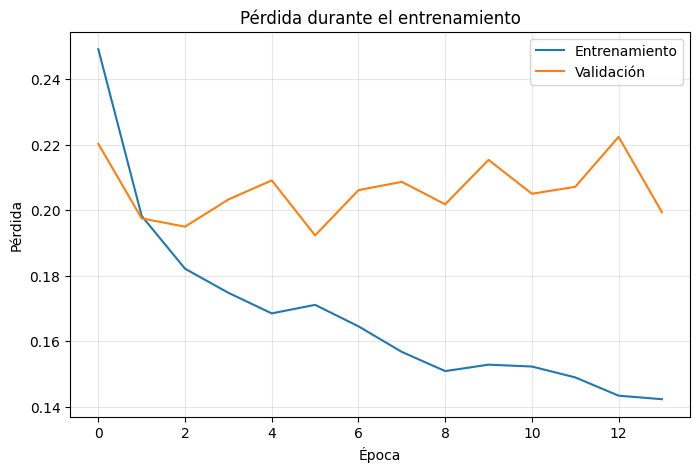

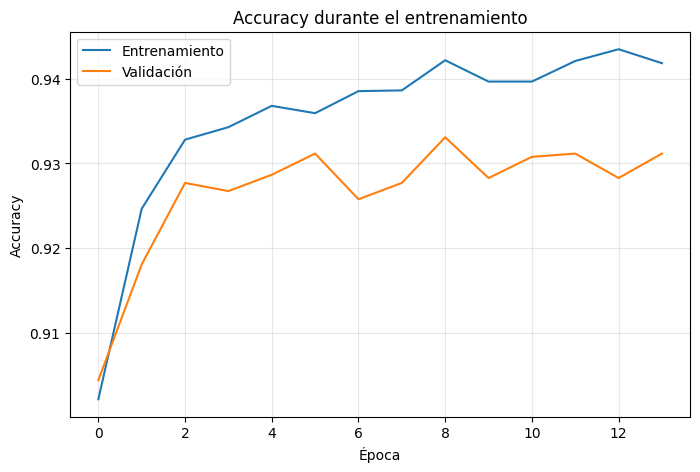

In [49]:
# ============================================================
# 21. CURVAS DE ENTRENAMIENTO DEL MLP
# ============================================================

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Entrenamiento")
plt.plot(history_df["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Pérdida durante el entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Entrenamiento")
plt.plot(history_df["val_accuracy"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

,modelo,accuracy,balanced_accuracy,precision,recall,f1
0,MLP,0.8621,0.8594,0.832,0.9218,0.8746


Reporte de clasificación del MLP:
              precision    recall  f1-score   support

 Sin temblor       0.90      0.80      0.85      1596
 Con temblor       0.83      0.92      0.87      1740

    accuracy                           0.86      3336
   macro avg       0.87      0.86      0.86      3336
weighted avg       0.87      0.86      0.86      3336



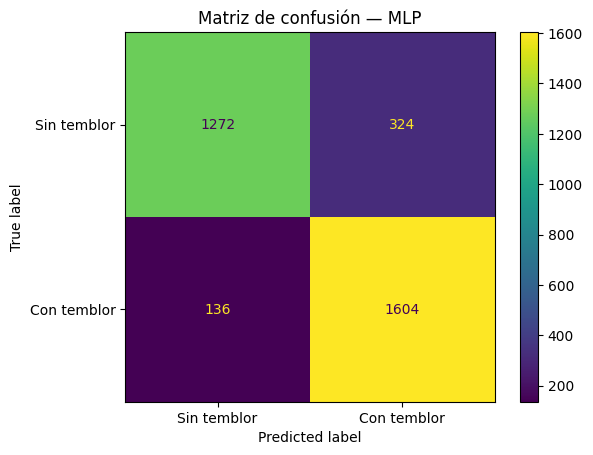

In [50]:
# ============================================================
# 22. EVALUACIÓN FINAL DEL MLP
# ============================================================

# Se obtienen las probabilidades predichas por el MLP para la clase con temblor
mlp_probability = mlp_model.predict(
    X_test_scaled,
    verbose=0,
).reshape(-1)

# Se convierten las probabilidades en clases usando umbral de 0.50
y_pred_mlp = (mlp_probability >= 0.50).astype(int)

# Se calculan las métricas principales del modelo en el conjunto de prueba
mlp_metrics = {
    "modelo": "MLP",
    "accuracy": accuracy_score(y_test, y_pred_mlp),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        y_pred_mlp,
    ),
    "precision": precision_score(
        y_test,
        y_pred_mlp,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        y_pred_mlp,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test,
        y_pred_mlp,
        zero_division=0,
    ),
}

# Se muestra la tabla resumen de métricas
display(pd.DataFrame([mlp_metrics]).round(4))

# Se imprime el reporte detallado por clase
print("Reporte de clasificación del MLP:")
print(
    classification_report(
        y_test,
        y_pred_mlp,
        target_names=["Sin temblor", "Con temblor"],
        zero_division=0,
    )
)

# Se calcula la matriz de confusión del MLP
mlp_matrix = confusion_matrix(y_test, y_pred_mlp)

# Se prepara la visualización de la matriz de confusión
mlp_display = ConfusionMatrixDisplay(
    confusion_matrix=mlp_matrix,
    display_labels=["Sin temblor", "Con temblor"],
)

# Se grafica la matriz de confusión
mlp_display.plot()
plt.title("Matriz de confusión — MLP")
plt.show()

In [51]:
# ============================================================
# 23. COMPARACIÓN DE RESULTADOS
# ============================================================

comparison = (
    pd.DataFrame([classical_metrics, mlp_metrics])
    .sort_values(
        by=["f1", "balanced_accuracy"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(comparison.round(4))

best_final_name = comparison.loc[0, "modelo"]
print("Mejor resultado en prueba:", best_final_name)

,modelo,accuracy,balanced_accuracy,precision,recall,f1
0,Regresión Logística sin PCA,0.8639,0.8603,0.8215,0.9443,0.8786
1,MLP,0.8621,0.8594,0.8320,0.9218,0.8746


Mejor resultado en prueba: Regresión Logística sin PCA


## Simulación de alerta

Una única ventana positiva puede ser un falso positivo. Por ello, la alerta se activa cuando se detecta temblor en **tres ventanas consecutivas**. Con ventanas de dos segundos y desplazamiento de un segundo, esta regla exige persistencia temporal antes de avisar.

En una implementación real, la alerta podría enviarse al teléfono del paciente o de un cuidador, pero requeriría validación clínica, seguridad, consentimiento y protección de datos.

In [52]:
# ============================================================
# 24. PROBABILIDADES DEL MODELO CLÁSICO
# ============================================================

def get_positive_probability(model, X_values):
    """
    Obtiene la probabilidad de pertenecer a la clase positiva.
    """

    # Si el modelo entrega probabilidades, se usa la probabilidad de la clase 1
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_values)[:, 1]

    # Si el modelo entrega una puntuación, se convierte a un valor entre 0 y 1
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_values)
        return 1.0 / (1.0 + np.exp(-scores))

    # Si no tiene probabilidades, se usa la predicción directa como aproximación
    return model.predict(X_values).astype(float)

# Se obtienen las probabilidades del mejor modelo clásico en prueba
classical_probability = get_positive_probability(
    best_classical_model,
    X_test,
)

# Se recupera la información de las ventanas del conjunto de prueba
test_predictions = features_df.iloc[test_index][[
    "group",
    "subject",
    "week",
    "segment",
    "start_time_ms",
    "target",
]].copy()

# Se guardan las probabilidades calculadas por cada modelo
test_predictions["prob_classical"] = classical_probability
test_predictions["prob_mlp"] = mlp_probability

# Se usa el modelo con mejor F1 final para simular las alertas
if best_final_name == "MLP":
    test_predictions["prob_tremor"] = test_predictions["prob_mlp"]
    alert_model_name = "MLP"
else:
    test_predictions["prob_tremor"] = test_predictions["prob_classical"]
    alert_model_name = best_pipeline_name

# Se convierte la probabilidad en predicción binaria usando umbral de 0.50
test_predictions["pred_tremor"] = (
    test_predictions["prob_tremor"] >= 0.50
).astype(int)

# Se ordenan las predicciones por sujeto, semana y tiempo
test_predictions = test_predictions.sort_values(
    ["subject", "week", "start_time_ms"]
).reset_index(drop=True)

# Se muestra el modelo usado y las primeras predicciones
print("Modelo usado para simular alertas:", alert_model_name)
display(test_predictions.head())

Modelo usado para simular alertas: Regresión Logística sin PCA


,group,subject,week,segment,start_time_ms,target,prob_classical,prob_mlp,prob_tremor,pred_tremor
0,REMOTE,REMOTE_S01,1,1,0.0,0,0.041434,0.199395,0.041434,0
1,REMOTE,REMOTE_S01,1,1,982.0,0,0.023601,0.014306,0.023601,0
2,REMOTE,REMOTE_S01,1,1,1964.0,0,0.052713,0.015700,0.052713,0
3,REMOTE,REMOTE_S01,1,1,2947.0,0,0.234907,0.407977,0.234907,0
4,REMOTE,REMOTE_S01,1,1,3930.0,0,0.205446,0.341034,0.205446,0


In [53]:
# ============================================================
# 25. REGLA DE TRES VENTANAS CONSECUTIVAS
# ============================================================

# Número de ventanas positivas seguidas necesarias para activar una alerta
ALERT_CONSECUTIVE_WINDOWS = 3

# Lista para guardar los resultados por sujeto y semana
alert_groups = []

# Se evalúa la regla de alerta por cada sujeto y semana
for (_, _), group_df in test_predictions.groupby(
    ["subject", "week"],
    sort=False,
):
    group_df = group_df.copy()

    # Suma móvil de las predicciones positivas en las últimas 3 ventanas
    consecutive_sum = (
        group_df["pred_tremor"]
        .rolling(
            window=ALERT_CONSECUTIVE_WINDOWS,
            min_periods=ALERT_CONSECUTIVE_WINDOWS,
        )
        .sum()
    )

    # La alerta se activa si las 3 ventanas consecutivas son positivas
    group_df["alert_active"] = (
        consecutive_sum >= ALERT_CONSECUTIVE_WINDOWS
    )

    # Estado de alerta en la ventana anterior
    previous_state = (
        group_df["alert_active"]
        .shift(1)
        .fillna(False)
        .astype(bool)
    )

    # Se marca solo el inicio de una nueva alerta
    group_df["new_alert"] = (
        group_df["alert_active"] & ~previous_state
    )

    # Se guarda el resultado del grupo procesado
    alert_groups.append(group_df)

# Se unen nuevamente todos los grupos procesados
alert_predictions = pd.concat(
    alert_groups,
    ignore_index=True,
)

# Se filtran únicamente las ventanas donde empieza una alerta
alerts = alert_predictions[
    alert_predictions["new_alert"]
].copy()

print("Cantidad de alertas generadas:", len(alerts))

# Si no hubo alertas, se muestra un mensaje
if len(alerts) == 0:
    print("No se activaron alertas en el conjunto de prueba.")

else:
    # Se muestran las primeras alertas generadas
    display(
        alerts[[
            "subject",
            "week",
            "start_time_ms",
            "prob_tremor",
            "target",
        ]].head(20)
    )

    # Se imprime una simulación de mensajes de alerta
    for _, alert in alerts.head(10).iterrows():
        print(
            "ALERTA DE PROTOTIPO | "
            f"Sujeto: {alert['subject']} | "
            f"Semana: {int(alert['week'])} | "
            f"Tiempo: {alert['start_time_ms'] / 1000:.1f} s | "
            f"Probabilidad: {alert['prob_tremor']:.3f}"
        )

Cantidad de alertas generadas: 95


,subject,week,start_time_ms,prob_tremor,target
37,REMOTE_S01,1,39429.0,0.919545,1
52,REMOTE_S01,1,54176.0,0.998846,1
60,REMOTE_S01,1,112895.0,0.676175,1
90,REMOTE_S01,1,163052.0,0.967182,1
108,REMOTE_S01,1,197811.0,0.965388,1
267,REMOTE_S01,2,55165.0,0.589110,0
287,REMOTE_S01,2,122490.0,0.593736,1
296,REMOTE_S01,2,147883.0,0.998522,1
311,REMOTE_S01,2,162610.0,0.841863,1
329,REMOTE_S01,2,196409.0,0.950127,1


ALERTA DE PROTOTIPO | Sujeto: REMOTE_S01 | Semana: 1 | Tiempo: 39.4 s | Probabilidad: 0.920
ALERTA DE PROTOTIPO | Sujeto: REMOTE_S01 | Semana: 1 | Tiempo: 54.2 s | Probabilidad: 0.999
ALERTA DE PROTOTIPO | Sujeto: REMOTE_S01 | Semana: 1 | Tiempo: 112.9 s | Probabilidad: 0.676
ALERTA DE PROTOTIPO | Sujeto: REMOTE_S01 | Semana: 1 | Tiempo: 163.1 s | Probabilidad: 0.967
ALERTA DE PROTOTIPO | Sujeto: REMOTE_S01 | Semana: 1 | Tiempo: 197.8 s | Probabilidad: 0.965
ALERTA DE PROTOTIPO | Sujeto: REMOTE_S01 | Semana: 2 | Tiempo: 55.2 s | Probabilidad: 0.589
ALERTA DE PROTOTIPO | Sujeto: REMOTE_S01 | Semana: 2 | Tiempo: 122.5 s | Probabilidad: 0.594
ALERTA DE PROTOTIPO | Sujeto: REMOTE_S01 | Semana: 2 | Tiempo: 147.9 s | Probabilidad: 0.999
ALERTA DE PROTOTIPO | Sujeto: REMOTE_S01 | Semana: 2 | Tiempo: 162.6 s | Probabilidad: 0.842
ALERTA DE PROTOTIPO | Sujeto: REMOTE_S01 | Semana: 2 | Tiempo: 196.4 s | Probabilidad: 0.950


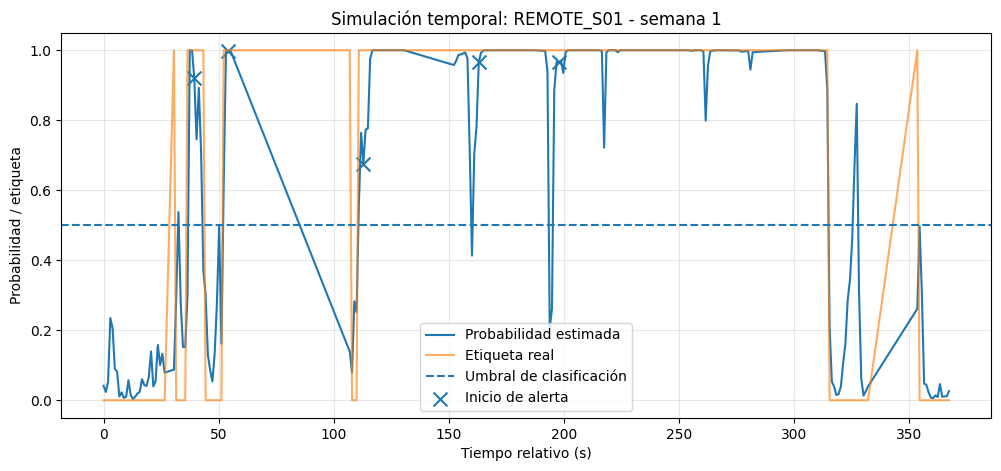

In [54]:
# ============================================================
# 26. VISUALIZACIÓN DE PROBABILIDAD Y ALERTAS
# ============================================================

# Se selecciona un sujeto de ejemplo para visualizar su comportamiento temporal
example_subject = alert_predictions["subject"].iloc[0]

# Se toma una semana de ejemplo de ese mismo sujeto
example_week = alert_predictions[
    alert_predictions["subject"] == example_subject
]["week"].iloc[0]

# Se filtran los datos del sujeto y semana seleccionados
timeline = alert_predictions[
    (alert_predictions["subject"] == example_subject)
    & (alert_predictions["week"] == example_week)
].copy()

# Se crea un tiempo relativo en segundos para facilitar la visualización
timeline["relative_time_s"] = (
    timeline["start_time_ms"] - timeline["start_time_ms"].min()
) / 1000

# Se crea la figura
plt.figure(figsize=(12, 5))

# Se grafica la probabilidad estimada de temblor
plt.plot(
    timeline["relative_time_s"],
    timeline["prob_tremor"],
    label="Probabilidad estimada",
)

# Se grafica la etiqueta real para comparar con la predicción
plt.plot(
    timeline["relative_time_s"],
    timeline["target"],
    label="Etiqueta real",
    alpha=0.65,
)

# Se dibuja el umbral usado para clasificar una ventana como temblor
plt.axhline(
    0.50,
    linestyle="--",
    label="Umbral de clasificación",
)

# Se marcan los puntos donde inicia una nueva alerta
plt.scatter(
    timeline.loc[timeline["new_alert"], "relative_time_s"],
    timeline.loc[timeline["new_alert"], "prob_tremor"],
    marker="x",
    s=100,
    label="Inicio de alerta",
)

# Etiquetas y título del gráfico
plt.xlabel("Tiempo relativo (s)")
plt.ylabel("Probabilidad / etiqueta")
plt.title(
    f"Simulación temporal: {example_subject} - semana {int(example_week)}"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [55]:
# ============================================================
# 27. GUARDADO DE MODELOS Y RESULTADOS
# ============================================================

CLASSICAL_MODEL_PATH = "/content/modelo_clasico_temblor.joblib"
MLP_SCALER_PATH = "/content/escalador_mlp.joblib"
MLP_MODEL_PATH = "/content/modelo_mlp_temblor.keras"
PREDICTIONS_PATH = "/content/predicciones_y_alertas.csv"
CV_RESULTS_PATH = "/content/resultados_validacion_cruzada.csv"
FINAL_RESULTS_PATH = "/content/resultados_finales.csv"

joblib.dump(best_classical_model, CLASSICAL_MODEL_PATH)
joblib.dump(mlp_scaler, MLP_SCALER_PATH)
mlp_model.save(MLP_MODEL_PATH)

alert_predictions.to_csv(PREDICTIONS_PATH, index=False)
cv_results.to_csv(CV_RESULTS_PATH, index=False)
comparison.to_csv(FINAL_RESULTS_PATH, index=False)

print("Archivos generados:")
print("-", CLASSICAL_MODEL_PATH)
print("-", MLP_SCALER_PATH)
print("-", MLP_MODEL_PATH)
print("-", PREDICTIONS_PATH)
print("-", CV_RESULTS_PATH)
print("-", FINAL_RESULTS_PATH)
print("-", FEATURES_PATH)

Archivos generados:
- /content/modelo_clasico_temblor.joblib
- /content/escalador_mlp.joblib
- /content/modelo_mlp_temblor.keras
- /content/predicciones_y_alertas.csv
- /content/resultados_validacion_cruzada.csv
- /content/resultados_finales.csv
- /content/monipar_tremor_features.csv


### Criterio principal

Para este problema se prioriza **F1**, ya que combina precisión y sensibilidad. La sensibilidad también es importante porque un falso negativo representa un episodio de temblor no detectado. Sin embargo, una sensibilidad alta con precisión baja produciría demasiadas alertas falsas.

### Limitaciones

- La base contiene pocos participantes.
- Las ventanas de una misma persona pueden estar correlacionadas.
- Los datos fueron obtenidos durante ejercicios guiados y no representan todas las situaciones cotidianas.
- Las etiquetas disponibles cubren temblor ligero y leve, no todos los niveles posibles.
- El prototipo no ha sido validado para uso clínico ni para tomar decisiones médicas.

## Implicancias éticas

- Obtener consentimiento informado para recolectar señales de movimiento.
- Proteger los identificadores y cifrar la información transmitida.
- Evitar presentar la predicción como diagnóstico.
- Informar que pueden existir falsos positivos y falsos negativos.
- Evaluar el desempeño por persona para detectar sesgos.
- Permitir que el usuario controle quién recibe las alertas.

## Referencias

1. SIGCHA, Luis y otros. 2023. “Monipar: movement data collection tool to monitor motor symptoms in Parkinson’s disease using smartwatches and smartphones”. *Frontiers in Neurology*, volumen 14, artículo 1326640. https://doi.org/10.3389/fneur.2023.1326640  
2. SIGCHA, Luis y otros. 2021. “Automatic Resting Tremor Assessment in Parkinson’s Disease Using Smartwatches and Multitask Convolutional Neural Networks”. *Sensors*, volumen 21, número 1, artículo 291. https://doi.org/10.3390/s21010291  
3. SAN-SEGUNDO, Rubén y otros. 2020. “Parkinson’s Disease Tremor Detection in the Wild Using Wearable Accelerometers”. *Sensors*, volumen 20, número 20, artículo 5817. https://doi.org/10.3390/s20205817  
4. SIGCHA, Luis y otros. 2023. *Monipar Database: smartwatch movement data to monitor motor competency in subjects with Parkinson’s disease* [base de datos]. Zenodo. https://doi.org/10.5281/zenodo.8104853  

## Declaración de uso de inteligencia artificial

Se utilizó una herramienta de inteligencia artificial como apoyo para estructurar y comentar parte del código.